![imagen](https://cdn.foodbeast.com/content/wp-content/uploads/2012/03/beer-print-01-selectism.jpg)

# Ejercicio pandas estadística
Para este ejercicio se ha utilizado [un dataset de un concurso de kaggle](https://www.kaggle.com/nickhould/craft-cans), cuyo reto consiste en predecir el tipo de cerveza en función de sus características (nivel de alcohol, amargura, tamaño...).

# Ejercicio 1
Importa las librerias que consideres

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns

## Ejercicio 2
1. Importa el dataset "datasets_beer.csv"
2. Imprime por pantalla los primeros registros.
3. ¿Cuáles son sus columnas?
4. ¿Qué dimensiones tiene el DataFrame?

In [89]:
birras = pd.read_csv(".\\data\\datasets_beers.csv")
birras.head(20)

,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
5,5,0.077,NaN,2261,Black Exodus,Oatmeal Stout,177,12.0
6,6,0.045,NaN,2260,Lake Street Express,American Pale Ale (APA),177,12.0
7,7,0.065,NaN,2259,Foreman,American Porter,177,12.0
8,8,0.055,NaN,2258,Jade,American Pale Ale (APA),177,12.0
9,9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0


In [90]:
birras.columns

Index(['Unnamed: 0', 'abv', 'ibu', 'id', 'name', 'style', 'brewery_id',
       'ounces'],
      dtype='str')

In [91]:
birras.shape

(2410, 8)

## Ejercicio 3
[Elimina la columna "Unnamed: 0"](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

In [92]:
birras.drop(columns=['Unnamed: 0'], inplace=True)
birras

,abv,ibu,id,name,style,brewery_id,ounces
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0


## Ejercicio 4
¿Cuántas filas y columnas tiene el dataset?

In [93]:
birras.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu         1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   str    
 4   style       2405 non-null   str    
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 131.9 KB


## Ejercicio 5
¿De qué tipo son los datos?

In [94]:
birras.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu         1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   str    
 4   style       2405 non-null   str    
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 131.9 KB


## Ejercicio 6
Obtén en un nuevo DataFrame un resumen con las principales estadísticas de las columnas numéricas: mean, max, count, cuartiles...

In [95]:
# Opción 1: Seleccionar solo columnas numéricas con select_dtypes
birras_details = birras.select_dtypes(include=[np.number]).aggregate([min, "max", np.mean])
birras_details

,abv,ibu,id,brewery_id,ounces
min,0.001000,NaN,1.000000,0.000000,8.400000
max,0.128000,138.000000,2692.000000,557.000000,32.000000
mean,0.059773,42.713167,1431.113278,231.749793,13.592241


## Ejercicio 7
¿Cuántas birras hay de cada estilo en este dataset? [Investiga en la documentación de Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html) si puedes hacer un conteo de valores.

In [96]:
birras["style"].value_counts()

style
American IPA                      424
American Pale Ale (APA)           245
American Amber / Red Ale          133
American Blonde Ale               108
American Double / Imperial IPA    105
                                 ... 
American Malt Liquor                1
Grisette                            1
Flanders Oud Bruin                  1
Braggot                             1
Low Alcohol Beer                    1
Name: count, Length: 99, dtype: int64

## Ejercicio 8
1. Imprime por pantalla los registros desde el décimo hasta el vigésimo
2. De esos registros, imprime por pantalla desde la columna `name` a `ounces`, ambas incluidas
3. Quédate con las columnas `abv`, `ibu` y `ounces`, y además quédate sólo con los registros 10 al 20.
4. Convierte el resultado del apartado 3 en un array de `numpy`

In [97]:
birras[9:20].loc[:, "name":"ounces"]

,name,style,brewery_id,ounces
9,Cone Crusher,American Double / Imperial IPA,177,12.0
10,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,Troll Destroyer,Belgian IPA,177,12.0
14,Bitter Bitch,American Pale Ale (APA),177,12.0
15,Ginja Ninja,Cider,154,12.0
16,Cherried Away,Cider,154,12.0
17,Rhubarbarian,Cider,154,12.0
18,BrightCider,Cider,154,12.0


In [98]:
birra10 = birras[9:20][["abv", "ibu", "ounces"]]

In [99]:
birras.to_numpy()

array([[0.05, nan, 1436, ..., 'American Pale Lager', 408, 12.0],
       [0.066, nan, 2265, ..., 'American Pale Ale (APA)', 177, 12.0],
       [0.071, nan, 2264, ..., 'American IPA', 177, 12.0],
       ...,
       [0.055, nan, 620, ..., 'Schwarzbier', 424, 12.0],
       [0.055, 40.0, 145, ..., 'American Pale Ale (APA)', 424, 12.0],
       [0.052, nan, 84, ..., 'American Amber / Red Ale', 424, 12.0]],
      shape=(2410, 7), dtype=object)

## Ejercicio 9
¿Cuántas onzas pesan todas las birras del dataset?

In [100]:
birras["ounces"].sum()

np.float64(32757.3)

## Ejercicio 10
El amargor de las cervezas se mide por su nivel de IBUs.
1. ¿Cuál es el amargor medio de las cervezas?
2. ¿El máximo? ¿Y el mínimo?
3. ¿Qué cerveza es la que tiene el amargor máximo? ¿Cuál es la de amargor mínimo?

In [101]:
ibu_median = birras["ibu"].median()
print("El valor medio del amargor (IBU) es:", ibu_median)

El valor medio del amargor (IBU) es: 35.0


In [102]:
max_ibu = birras["ibu"].max()
min_ibu = birras["ibu"].min()
print("El valor máximo del amargor (IBU) es:", max_ibu)
print("El valor mínimo del amargor (IBU) es:", min_ibu) 

El valor máximo del amargor (IBU) es: 138.0
El valor mínimo del amargor (IBU) es: 4.0


In [103]:
birras[["name", "ibu"]][birras["ibu"] == birras["ibu"].max()]

,name,ibu
147,Bitter Bitch Imperial IPA,138.0


In [104]:
birras[["name", "ibu"]][birras["ibu"] == birras["ibu"].min()]

,name,ibu
106,Summer Solstice,4.0
112,Summer Solstice Cerveza Crema (2009),4.0
117,Summer Solstice (2011),4.0


In [105]:
birras["ibu"].mean()

np.float64(42.71316725978647)

## Ejercicio 11
No queda muy claro cuánto de dispar, de dispersa, es la medida de IBU. Mediante estadística descriptiva (una o dos métricas, sin gráficas), razona la dispersión de la variable IBU.

# 📊 Dispersión de datos de IBU

* **MÁX** = 138
* **MÍN** = 4
* **Mediana** = 35
* **Media** = 42,71

---

### Análisis de la distribución 🍺

Los valores de amargor (**IBU**) se encuentran en una **horquilla amplia** que se extiende desde su valor mínimo hasta su punto máximo de 138.

Sin embargo, observamos que tanto la **media** como la **mediana** tienden a agruparse en torno a valores bajos. Por lo tanto, podemos deducir que la mayoría de los datos se concentran en un margen de entre **30 y 45 IBU**. 📈

<Axes: ylabel='ibu'>

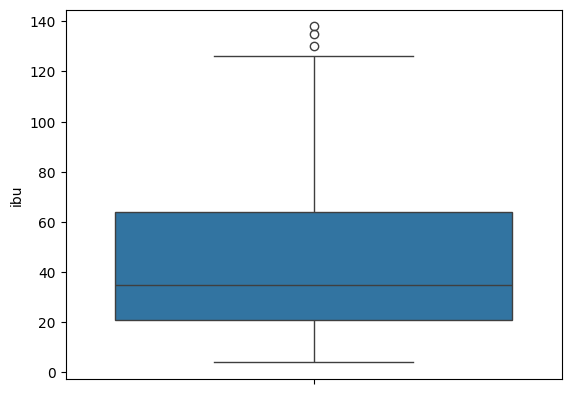

In [106]:
sns.boxplot(y=birras["ibu"])

## Ejercicio 12
¿Existe alguna relación lineal entre las variables numéricas del dataset? Intenta pintar este razonamiento mediante un gráfico

<Axes: xlabel='abv', ylabel='ibu'>

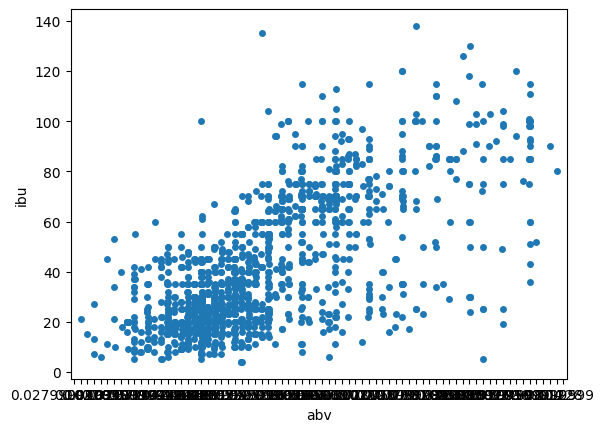

In [107]:
sns.stripplot(data=birras, x='abv', y='ibu')

En esta gráfica vemos una relacción directa entre la graduación alcoholica y el amargor, comprobando que a mayor graduación suelen ser mas amargas.

## Ejercicio 13
Representa el nivel de alcohol (columna `abv`) en un histograma. ¿Se trata de una distribución simétrica o asimétrica?

<Axes: xlabel='abv', ylabel='Count'>

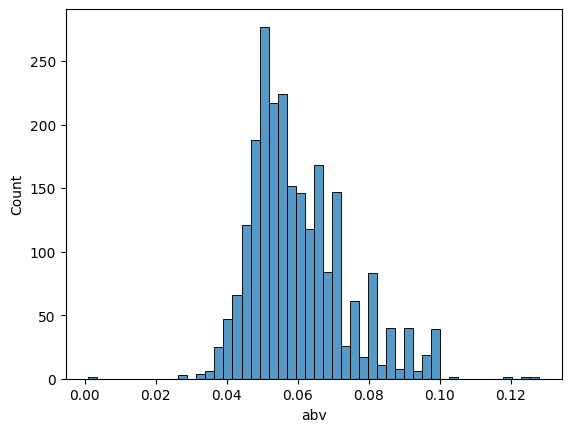

In [108]:
sns.histplot(data=birras, x='abv')

La gráfica es asimétrica ya que la mayoria de los datos tienden ser mayores a 0.05 que determinaria el eje de gráfica.

## Ejercicio 14
Representa mediante un *boxplot* de `seaborn` la variable `abv`

<Axes: xlabel='abv'>

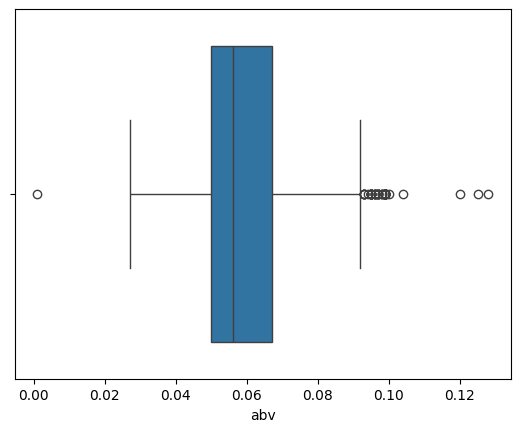

In [109]:
sns.boxplot(data=birras, x='abv')

## Ejercicio 15
1. ¿Qué estilos son los que tienen en media más alcohol?
2. ¿Y los estilos que son en media más amargos?

In [116]:
birras["abv"].mean()

np.float64(0.05977342419080067)

In [ ]:
# Estilos con mayor contenido de alcohol en promedio
print("Estilos con mayor ABV (alcohol):")
birras['style']['abv'].mean()



SyntaxError: invalid syntax (1231606104.py, line 3)

In [111]:
print("\nEstilos más amargos (mayor IBU):")
ibu_by_style = birras.groupby('style')['ibu'].mean().sort_values(ascending=False)
print(ibu_by_style.head())


Estilos más amargos (mayor IBU):
style
American Barleywine                   96.00
American Double / Imperial IPA        93.32
Russian Imperial Stout                86.50
American Double / Imperial Pilsner    85.00
Belgian Strong Dark Ale               72.00
Name: ibu, dtype: float64


## Ejercicio 16
Carga el datasets de cervecerias `datasets_breweries.csv`

In [126]:
cervecerias = pd.read_csv(".\\data\\datasets_breweries.csv")
cervecerias.head(20)

,Unnamed: 0,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
5,5,COAST Brewing Company,Charleston,SC
6,6,Great Divide Brewing Company,Denver,CO
7,7,Tapistry Brewing,Bridgman,MI
8,8,Big Lake Brewing,Holland,MI
9,9,The Mitten Brewing Company,Grand Rapids,MI


## Ejercicio 17
1. Renombra la columna `Unnamed: 0` como `brewery_id`
2. Renombra también la columna `name` por `brewery_name`. ¿Puedes hacer ambos apartados en una sola sentencia?

In [129]:
cervecerias.rename(columns={"Unnamed: 0" : "brewery_id"})
cervecerias.rename(columns={"name" : "brewery_name"})

,brewery_id,brewery_name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 18
Junta los dos datasets que tienes

In [133]:
birras_merge = birras.merge(cervecerias, left_on="brewery_id", right_on="brewery_id", how="outer")
birras_merge

,abv,ibu,id,name_x,style,brewery_id,ounces,name_y,city,state
0,0.045,50.0,2692,Get Together,American IPA,0,16.0,NorthGate Brewing,Minneapolis,MN
1,0.049,26.0,2691,Maggie's Leap,Milk / Sweet Stout,0,16.0,NorthGate Brewing,Minneapolis,MN
2,0.048,19.0,2690,Wall's End,English Brown Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
3,0.060,38.0,2689,Pumpion,Pumpkin Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
4,0.060,25.0,2688,Stronghold,American Porter,0,16.0,NorthGate Brewing,Minneapolis,MN
...,...,...,...,...,...,...,...,...,...,...
2405,0.049,NaN,52,Heinnieweisse Weissebier,Hefeweizen,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2406,0.068,NaN,51,Snapperhead IPA,American IPA,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2407,0.049,NaN,50,Moo Thunder Stout,Milk / Sweet Stout,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2408,0.043,NaN,49,Porkslap Pale Ale,American Pale Ale (APA),556,12.0,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 19
1. ¿Cuántos estados diferentes hay?
2. ¿Y ciudades diferentes?
3. ¿Cuántas cervecerías hay?

In [135]:
birras_merge["state"].unique()

<StringArray>
[' MN', ' KY', ' MA', ' CA', ' SC', ' CO', ' MI', ' IN', ' TX', ' AZ', ' MO',
 ' WI', ' IL', ' VT', ' ME', ' PA', ' KS', ' NY', ' NH', ' GA', ' VA', ' FL',
 ' MD', ' NC', ' WY', ' OR', ' RI', ' CT', ' OH', ' AK', ' MS', ' AR', ' LA',
 ' WV', ' UT', ' ID', ' WA', ' OK', ' NE', ' HI', ' IA', ' SD', ' NJ', ' MT',
 ' DC', ' NV', ' TN', ' NM', ' AL', ' DE', ' ND']
Length: 51, dtype: str

In [136]:
birras_merge["city"].unique()

<StringArray>
[  'Minneapolis',    'Louisville',    'Framingham',     'San Diego',
 'San Francisco',    'Charleston',        'Denver',      'Bridgman',
       'Holland',  'Grand Rapids',
 ...
     'Lancaster',        'Elmira',  'North Conway',      'Prescott',
      'Pinedale',  'Libertyville',     'Covington',        'Wilson',
         'Ukiah', 'Garrattsville']
Length: 384, dtype: str

## Ejercicio 20
Agrupa por estado y ciudad, la media, mediana y máximo nivel de alcohol

In [150]:
birras_merge.groupby(["state", "city"])['abv'].aggregate([np.median, np.mean, np.max])

median      mean    max
state city                               
AK    Anchorage   0.0520  0.054200  0.063
      Juneau      0.0530  0.053000  0.053
      Soldotna    0.0580  0.058500  0.068
      Talkeetna   0.0585  0.059500  0.065
AL    Birmingham  0.0600  0.065400  0.093
...                  ...       ...    ...
WI    Wilson      0.0550  0.055000  0.055
WV    Lewisburg   0.0620  0.062000  0.067
WY    Jackson     0.0520  0.054857  0.068
      Pinedale    0.0610  0.061000  0.072
      Sheridan    0.0480  0.052833  0.070

[401 rows x 3 columns]

## Ejercicio 21
¿Cuáles son las cervezas más amargas que se consumen en Indiana, estado = `IN`?

In [159]:
birras_merge[birras_merge["state"] == " IN"].sort_values(by="ibu", ascending=False).head(3)

,abv,ibu,id,name_x,style,brewery_id,ounces,name_y,city,state
145,0.085,115.0,1449,Overlord Imperial IPA,American Double / Imperial IPA,17,16.0,Tin Man Brewing Company,Evansville,IN
166,0.099,115.0,2471,Hopkick Dropkick,American Double / Imperial IPA,24,12.0,Burn 'Em Brewing,Michigan City,IN
140,0.060,104.0,1610,Half Cycle IPA,American IPA,16,16.0,Flat 12 Bierwerks,Indianapolis,IN


## Ejercicio 22
Obtén una tabla con los principales estadísticos del campo `ibu`,  a nivel ciudad

In [163]:
birras_merge[["ibu"]].groupby(birras_merge["city"]).aggregate([np.median, np.mean, np.max])

ibu                   
               median        mean    max
city                                    
Abingdon        135.0  135.000000  135.0
Abita Springs    17.0   27.333333   52.0
Ada               NaN         NaN    NaN
Afton            45.0   43.000000   60.0
Airway Heights    NaN         NaN    NaN
...               ...         ...    ...
Woodinville      44.0   46.750000   72.0
Worcester        69.0   69.000000   69.0
Yakima           54.0   54.000000   70.0
Yardley           NaN         NaN    NaN
York             41.0   44.250000   75.0

[384 rows x 3 columns]

## Ejercicio 23
Consigue en un DataFrame de todas las cervezas en cuyas cervecerías al menos haya una cerveza con un `abv` mínimo 0.07.

In [191]:
birras_merge.groupby(["name_x", "name_y"], as_index=False)["abv"].apply(lambda x: x >= 0.07)[["name_x", "name_y", "abv"]]



KeyError: "None of [Index(['name_x', 'name_y', 'abv'], dtype='str')] are in the [index]"

In [192]:
birras_merge.groupby(["name_x", "name_y"])[["name_x", "name_y", "abv"]].filter(lambda x: (x["abv"] >= 0.07).any())

,name_x,name_y,abv
6,Citra Ass Down,Against the Grain Brewery,0.080
7,London Balling,Against the Grain Brewery,0.125
8,35 K,Against the Grain Brewery,0.077
14,Rico Sauvin,Against the Grain Brewery,0.076
21,Excess IPL,Jack's Abby Craft Lagers,0.072
...,...,...,...
2331,Triangle Belgian Golden Ale,Triangle Brewing Company,0.080
2343,Tour de Nez Belgian IPA (Current),Buckbean Brewing Company,0.080
2345,Black Adder IBA (Current),Buckbean Brewing Company,0.073
2346,Very Noddy Lager (Current),Buckbean Brewing Company,0.099


## Ejercicio 24
Teniendo en cuenta la media de amargor de todas las cervezas, obtén una tabla con las cervezas cuyos estados tengan una media de amargor en cerveza por encima de la media

In [208]:
ibu_mean = birras_merge["ibu"].mean()
print("El valor medio del amargor (IBU) es:", ibu_mean)
states_ibu_mean = birras_merge.groupby("state")["ibu"].mean() > ibu_mean
states_ibu_mean

El valor medio del amargor (IBU) es: 42.71316725978647


state
AK    False
AL     True
AR    False
AZ    False
CA     True
CO     True
CT    False
DC     True
DE     True
FL     True
GA     True
HI    False
IA    False
ID     True
IL    False
IN     True
KS    False
KY    False
LA    False
MA    False
MD    False
ME     True
MI    False
MN     True
MO    False
MS     True
MT    False
NC     True
ND    False
NE    False
NH     True
NJ     True
NM     True
NV     True
NY     True
OH     True
OK    False
OR     True
PA    False
RI    False
SC    False
SD    False
TN    False
TX    False
UT     True
VA     True
VT    False
WA     True
WI    False
WV     True
WY    False
Name: ibu, dtype: bool

In [227]:
pd.DataFrame(birras_merge[birras_merge["state"].isin(states_ibu_mean[states_ibu_mean].index)].groupby("state")["ibu"].mean())

,ibu
state,
AL,51.222222
CA,46.281481
CO,47.431507
DC,55.250000
DE,52.000000
FL,46.756757
GA,46.285714
ID,55.117647
IN,42.989011


In [220]:
birras_merge.groupby("state").filter(lambda x: x["ibu"].mean() > ibu_mean)

,abv,ibu,id,name_x,style,brewery_id,ounces,name_y,city,state
0,0.045,50.0,2692,Get Together,American IPA,0,16.0,NorthGate Brewing,Minneapolis,MN
1,0.049,26.0,2691,Maggie's Leap,Milk / Sweet Stout,0,16.0,NorthGate Brewing,Minneapolis,MN
2,0.048,19.0,2690,Wall's End,English Brown Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
3,0.060,38.0,2689,Pumpion,Pumpkin Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
4,0.060,25.0,2688,Stronghold,American Porter,0,16.0,NorthGate Brewing,Minneapolis,MN
...,...,...,...,...,...,...,...,...,...,...
2404,0.055,NaN,98,Pilsner Ukiah,German Pilsener,555,12.0,Ukiah Brewing Company,Ukiah,CA
2405,0.049,NaN,52,Heinnieweisse Weissebier,Hefeweizen,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2406,0.068,NaN,51,Snapperhead IPA,American IPA,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2407,0.049,NaN,50,Moo Thunder Stout,Milk / Sweet Stout,556,12.0,Butternuts Beer and Ale,Garrattsville,NY


In [199]:
birras_merge[birras_merge["state"].isin(birras_merge.groupby("state")["ibu"].mean()[birras_merge.groupby("state")["ibu"].mean() > ibu_mean].index)]

,abv,ibu,id,name_x,style,brewery_id,ounces,name_y,city,state
0,0.045,50.0,2692,Get Together,American IPA,0,16.0,NorthGate Brewing,Minneapolis,MN
1,0.049,26.0,2691,Maggie's Leap,Milk / Sweet Stout,0,16.0,NorthGate Brewing,Minneapolis,MN
2,0.048,19.0,2690,Wall's End,English Brown Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
3,0.060,38.0,2689,Pumpion,Pumpkin Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
4,0.060,25.0,2688,Stronghold,American Porter,0,16.0,NorthGate Brewing,Minneapolis,MN
...,...,...,...,...,...,...,...,...,...,...
2404,0.055,NaN,98,Pilsner Ukiah,German Pilsener,555,12.0,Ukiah Brewing Company,Ukiah,CA
2405,0.049,NaN,52,Heinnieweisse Weissebier,Hefeweizen,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2406,0.068,NaN,51,Snapperhead IPA,American IPA,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2407,0.049,NaN,50,Moo Thunder Stout,Milk / Sweet Stout,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
